In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

# Physical constants
MEC2 = 510.999  # keV
R_E = 2.8179e-13  # classical electron radius, cm
E0 = 59.54       # Am-241 primary line, keV

In [11]:
with open('omar_rishabh_weekendrun.mca', 'r', encoding='latin-1') as f:
    for i, line in enumerate(f):
        if i < 30: print(repr(line))
        else: break

'<<PMCA SPECTRUM>>\n'
'TAG - live_data\n'
'DESCRIPTION - \n'
'GAIN - 3\n'
'THRESHOLD - 0\n'
'LIVE_MODE - 0\n'
'PRESET_TIME - 0\n'
'LIVE_TIME - 116527.495624\n'
'REAL_TIME - 245424.380000\n'
'START_TIME - 04/24/2026 16:05:55\n'
'SERIAL_NUMBER - 10628\n'
'<<DATA>>\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'
'0\n'


In [9]:
def read_mca(filename):
    """Parse an Amptek/Maestro-style .mca file. Returns channels, counts, live_time."""
    with open(filename, 'r', encoding='latin-1') as f:
        text = f.read()
    
    # Extract live time from header if present
    live_time = None
    for line in text.splitlines():
        if line.startswith('LIVE_TIME'):
            # Handle both "LIVE_TIME - 12345" and "LIVE_TIME: 12345" styles
            parts = line.replace('-', ' ').replace(':', ' ').split()
            for p in parts[::-1]:
                try:
                    live_time = float(p)
                    break
                except ValueError:
                    continue
            break
    
    # Extract data block
    data_block = text.split('<<DATA>>')[1].split('<<END>>')[0]
    counts = np.array([int(x) for x in data_block.strip().splitlines()])
    channels = np.arange(len(counts))
    return channels, counts, live_time

channels, counts, live_time = read_mca('omar_rishabh_weekendrun.mca')
print(f"Live time: {live_time} s, total counts: {counts.sum()}")

Live time: 116527.495624 s, total counts: 1036913


Number of channels: 2048


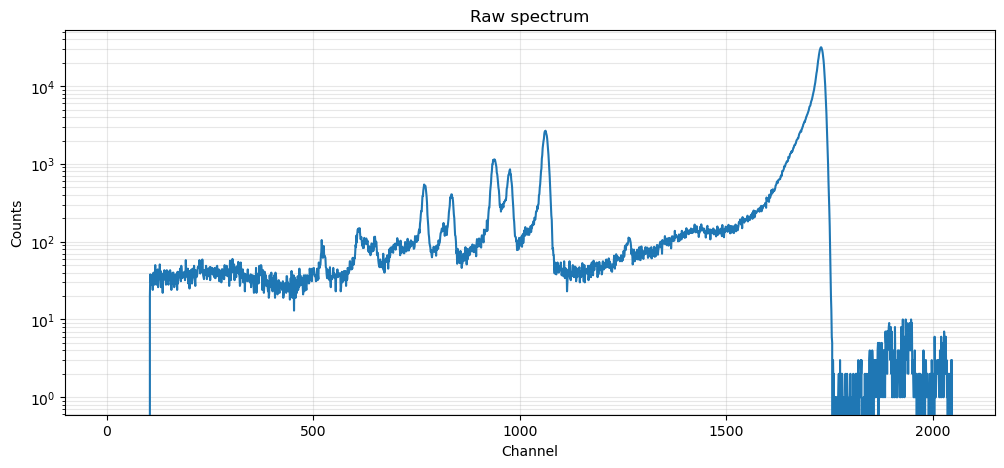

In [10]:
print(f"Number of channels: {len(counts)}")

plt.figure(figsize=(12,5))
plt.semilogy(channels, counts)
plt.xlabel('Channel'); plt.ylabel('Counts')
plt.title('Raw spectrum')
plt.grid(True, which='both', alpha=0.3)
plt.show()

Photopeak centroid: channel 1727.65, sigma = 7.84 ch
Calibration: 0.0345 keV/ch
Photopeak FWHM: 0.636 keV (1.07% at 59.54 keV)


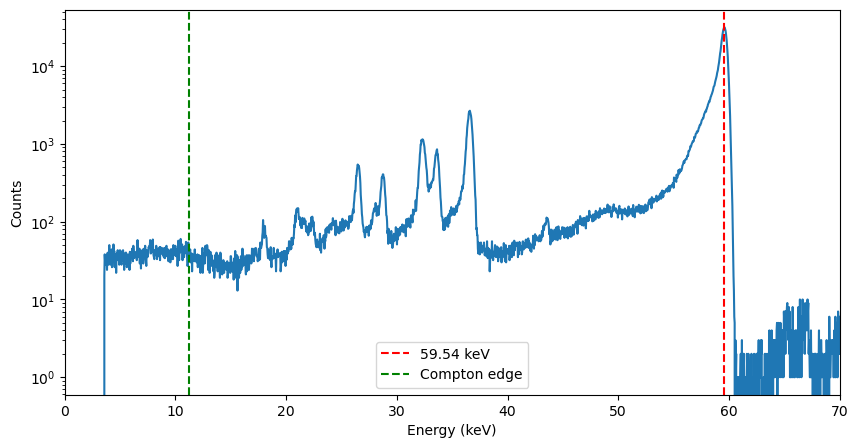

In [12]:
def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5*((x-mu)/sigma)**2) + c

# Find approximate photopeak channel — adjust the search window to where you see it
search_lo, search_hi = 1500, 2000   # CHANGE THESE based on your spectrum
region = slice(search_lo, search_hi)
peak_guess = search_lo + np.argmax(counts[region])

fit_window = 60  # channels on each side
x_fit = channels[peak_guess-fit_window : peak_guess+fit_window]
y_fit = counts[peak_guess-fit_window : peak_guess+fit_window]

popt, pcov = curve_fit(gaussian, x_fit, y_fit,
                       p0=[y_fit.max(), peak_guess, 10, y_fit.min()])
A_pk, ch_pk, sigma_pk, _ = popt
print(f"Photopeak centroid: channel {ch_pk:.2f}, sigma = {sigma_pk:.2f} ch")

# Linear calibration assuming zero offset (good enough if you only have one line)
keV_per_ch = E0 / ch_pk
energy = channels * keV_per_ch
sigma_pk_keV = sigma_pk * keV_per_ch
fwhm_keV = 2.355 * sigma_pk_keV
print(f"Calibration: {keV_per_ch:.4f} keV/ch")
print(f"Photopeak FWHM: {fwhm_keV:.3f} keV ({100*fwhm_keV/E0:.2f}% at 59.54 keV)")

plt.figure(figsize=(10,5))
plt.semilogy(energy, counts)
plt.axvline(E0, color='r', ls='--', label='59.54 keV')
plt.axvline(2*E0**2/(MEC2 + 2*E0), color='g', ls='--', label='Compton edge')
plt.xlim(0, 70)
plt.xlabel('Energy (keV)'); plt.ylabel('Counts')
plt.legend(); plt.show()

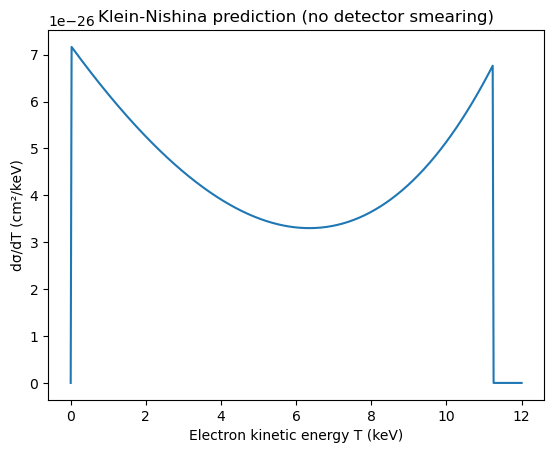

In [15]:
def klein_nishina_dsigma_dT(T, E=E0):
    """
    Klein-Nishina dσ/dT for Compton electron kinetic energy T (keV).
    Returns differential cross section in cm^2/keV per electron.
    Zero outside the kinematically allowed region.
    """
    T = np.atleast_1d(T).astype(float)
    T_max = 2*E**2 / (MEC2 + 2*E)
    out = np.zeros_like(T)
    mask = (T > 1e-6) & (T < T_max - 1e-6)
    
    Tm = T[mask]
    Eprime = E - Tm
    alpha = E / MEC2
    u = MEC2 * (1.0/Eprime - 1.0/E)   # this equals (1 - cosθ)
    bracket = (Eprime/E)**2 + (E/Eprime) - u*(2 - u)
    
    out[mask] = (np.pi * R_E**2 / (MEC2 * alpha**2)) * bracket
    return out

# Quick sanity plot
T_grid = np.linspace(0, 12, 500)
plt.plot(T_grid, klein_nishina_dsigma_dT(T_grid))
plt.xlabel('Electron kinetic energy T (keV)')
plt.ylabel('dσ/dT (cm²/keV)')
plt.title('Klein-Nishina prediction (no detector smearing)')
plt.show()

In [16]:
# Counts per keV
counts_per_keV = counts / keV_per_ch
counts_per_keV_err = np.sqrt(counts) / keV_per_ch  # Poisson

# Optional: rebin to reduce noise (factor of N)
def rebin(arr, n):
    end = (len(arr)//n)*n
    return arr[:end].reshape(-1, n).sum(axis=1)

rebin_factor = 4
E_binned = rebin(energy, rebin_factor) / rebin_factor
y_binned = rebin(counts, rebin_factor) / (rebin_factor * keV_per_ch)
yerr_binned = np.sqrt(rebin(counts, rebin_factor)) / (rebin_factor * keV_per_ch)

In [17]:
def sigma_of_E(E_keV, sigma_at_E0=sigma_pk_keV, E_ref=E0):
    """Energy resolution σ(E) assuming sqrt(E) scaling. Replace if you have better info."""
    return sigma_at_E0 * np.sqrt(np.maximum(E_keV, 0.1) / E_ref)

def kn_convolved(T_eval, E=E0, n_fine=4000):
    """Klein-Nishina convolved with energy-dependent Gaussian resolution."""
    T_max = 2*E**2 / (MEC2 + 2*E)
    # Fine grid covering the full kinematic range plus tails
    T_fine = np.linspace(-5, T_max + 10, n_fine)
    dT = T_fine[1] - T_fine[0]
    kn_fine = klein_nishina_dsigma_dT(T_fine, E)
    
    result = np.zeros_like(T_eval, dtype=float)
    for i, T in enumerate(T_eval):
        sig = sigma_of_E(T)
        kernel = np.exp(-0.5*((T_fine - T)/sig)**2) / (np.sqrt(2*np.pi)*sig)
        result[i] = np.sum(kn_fine * kernel) * dT
    return result

In [18]:
# Pick the fitting region: above the noise threshold, below the multiple-scattering 
# region that fills in between the Compton edge and the photopeak.
fit_lo, fit_hi = 2.0, 10.0   # keV — adjust based on your spectrum
fit_mask = (E_binned > fit_lo) & (E_binned < fit_hi)

E_data = E_binned[fit_mask]
y_data = y_binned[fit_mask]
y_err  = np.maximum(yerr_binned[fit_mask], 1.0)

def model(T, amplitude, background):
    return amplitude * kn_convolved(T) + background

p0 = [y_data.mean() / kn_convolved(np.array([5.0]))[0], 0.0]
popt, pcov = curve_fit(model, E_data, y_data, p0=p0, sigma=y_err, absolute_sigma=True)
amp, bg = popt
print(f"Best-fit amplitude = {amp:.3e}, background = {bg:.3e}")

# Reduced chi-squared
chi2 = np.sum(((y_data - model(E_data, *popt))/y_err)**2)
dof = len(y_data) - len(popt)
print(f"chi²/dof = {chi2:.1f}/{dof} = {chi2/dof:.2f}")

Best-fit amplitude = -5.421e+26, background = 2.578e+01
chi²/dof = 7096.5/56 = 126.72


/tmp/ipykernel_581590/579308143.py:28: RuntimeWarning: divide by zero encountered in divide
  residuals = (y_binned - model_at_data) / yerr_binned


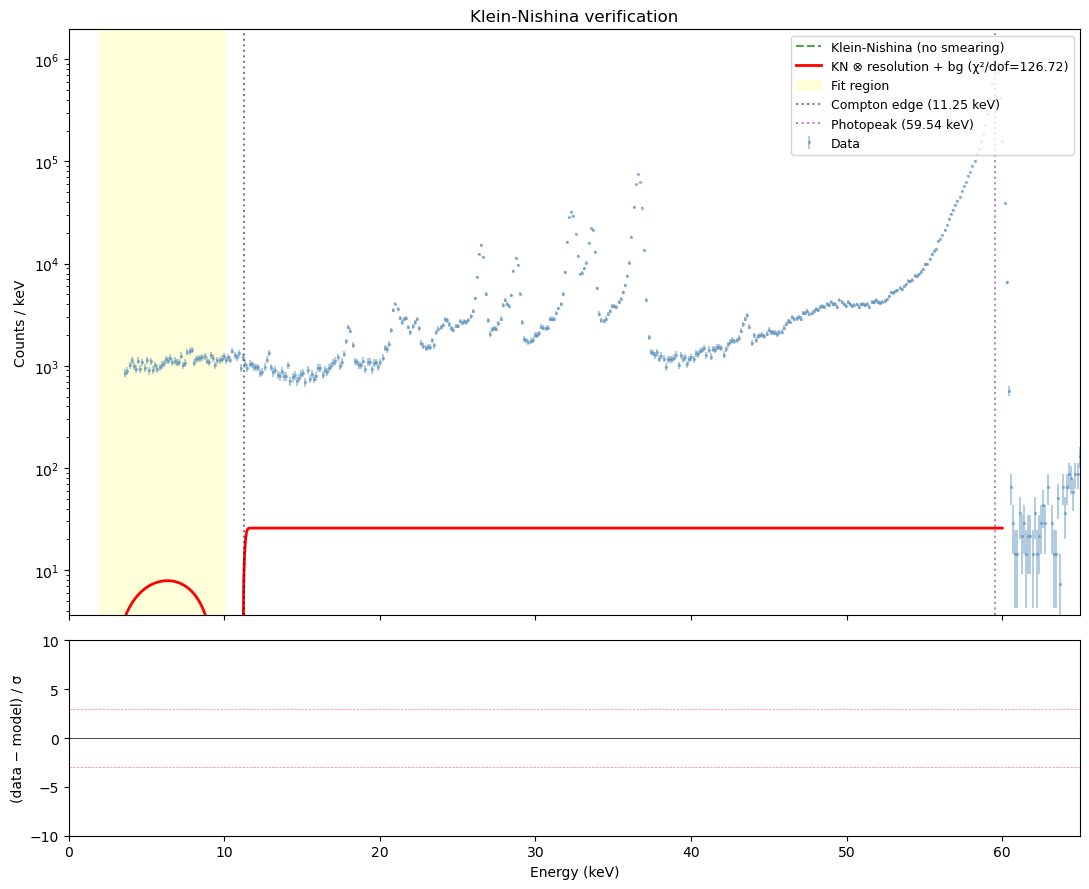

In [22]:
T_plot = np.linspace(0.1, 60, 1000)
model_plot = model(T_plot, *popt)
kn_plot_unconv = amp * klein_nishina_dsigma_dT(T_plot)

T_max = 2*E0**2 / (MEC2 + 2*E0)

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'height_ratios':[3,1]})
ax = axes[0]
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.4,
            label='Data', color='steelblue')
ax.plot(T_plot, kn_plot_unconv, 'g--', lw=1.5, alpha=0.7,
        label='Klein-Nishina (no smearing)')
ax.plot(T_plot, model_plot, 'r-', lw=2,
        label=f'KN ⊗ resolution + bg (χ²/dof={chi2/dof:.2f})')
ax.axvspan(fit_lo, fit_hi, color='yellow', alpha=0.15, label='Fit region')
ax.axvline(T_max, color='k', ls=':', alpha=0.5, label=f'Compton edge ({T_max:.2f} keV)')
ax.axvline(E0, color='purple', ls=':', alpha=0.5, label='Photopeak (59.54 keV)')
ax.set_ylabel('Counts / keV')
ax.set_yscale('log')
ax.set_ylim(bottom=max(1, y_binned[y_binned>0].min()*0.5))
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Klein-Nishina verification')

# Residuals panel
ax2 = axes[1]
model_at_data = model(E_binned, *popt)
residuals = (y_binned - model_at_data) / yerr_binned
in_fit = (E_binned > fit_lo) & (E_binned < fit_hi)
ax2.plot(E_binned[in_fit], residuals[in_fit], '.', ms=3, color='steelblue')
ax2.axhline(0, color='k', lw=0.5)
ax2.axhline(3, color='r', ls='--', lw=0.5, alpha=0.5)
ax2.axhline(-3, color='r', ls='--', lw=0.5, alpha=0.5)
ax2.set_xlabel('Energy (keV)')
ax2.set_ylabel('(data − model) / σ')
ax2.set_xlim(0, 65)
ax2.set_ylim(-10, 10)
plt.tight_layout()
plt.show()

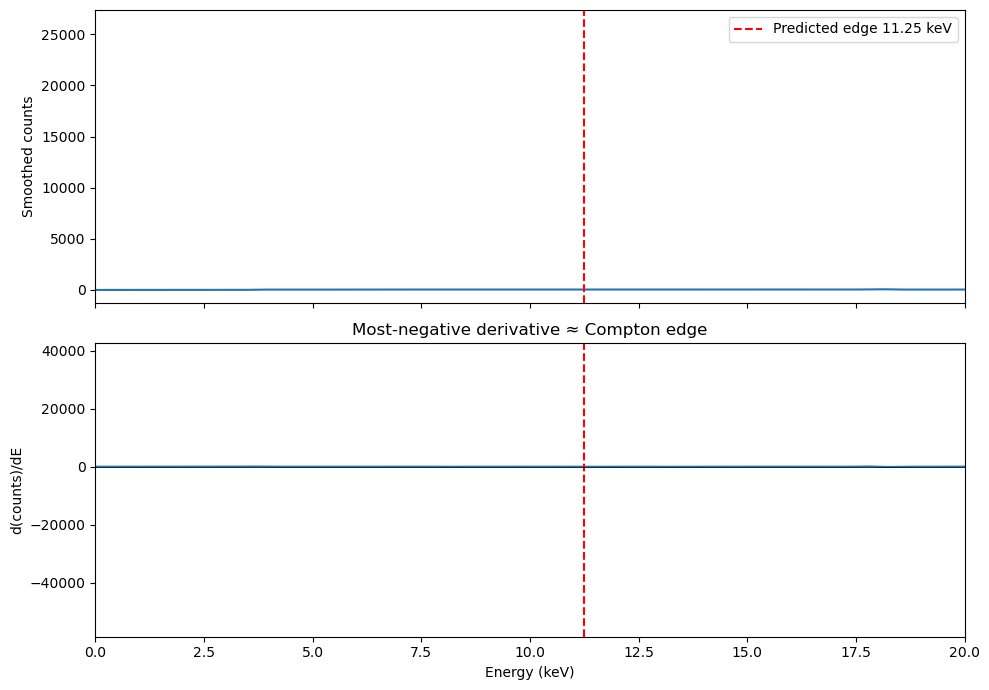

Measured Compton edge: 13.03 keV (predicted: 11.25 keV)
  → calibration off by factor 0.8638


In [24]:
# The Compton edge should be a clear inflection. Find it numerically by 
# looking at the derivative of the smoothed spectrum.
from scipy.ndimage import gaussian_filter1d

smooth = gaussian_filter1d(counts.astype(float), sigma=5)
deriv = np.gradient(smooth, energy)

fig, axes = plt.subplots(2, 1, figsize=(10,7), sharex=True)
axes[0].plot(energy, smooth)
axes[0].axvline(T_max, color='r', ls='--', label=f'Predicted edge {T_max:.2f} keV')
axes[0].set_xlim(0, 20); axes[0].set_ylabel('Smoothed counts')
axes[0].legend()

axes[1].plot(energy, deriv)
axes[1].axvline(T_max, color='r', ls='--')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlim(0, 20); axes[1].set_xlabel('Energy (keV)')
axes[1].set_ylabel('d(counts)/dE')
axes[1].set_title('Most-negative derivative ≈ Compton edge')
plt.tight_layout(); plt.show()

edge_region = (energy > 5) & (energy < 15)
edge_measured = energy[edge_region][np.argmin(deriv[edge_region])]
print(f"Measured Compton edge: {edge_measured:.2f} keV (predicted: {T_max:.2f} keV)")
print(f"  → calibration off by factor {T_max/edge_measured:.4f}")

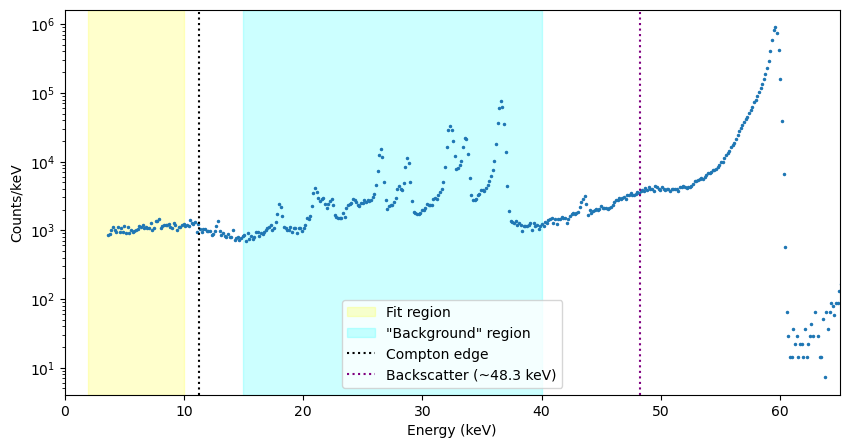

Mean counts/keV in 15-40 keV: 5427.40
  std: 10013.50
  expected std from Poisson: 198.42


In [25]:
fig, ax = plt.subplots(figsize=(10,5))
ax.semilogy(E_binned, y_binned, '.', ms=3)
ax.axvspan(fit_lo, fit_hi, color='yellow', alpha=0.2, label='Fit region')
ax.axvspan(15, 40, color='cyan', alpha=0.2, label='"Background" region')
ax.axvline(T_max, color='k', ls=':', label='Compton edge')
ax.axvline(E0 - T_max, color='purple', ls=':', label='Backscatter (~48.3 keV)')
ax.set_xlim(0, 65); ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts/keV')
ax.legend(); plt.show()

# Is it really flat between edge and photopeak?
bg_mask = (E_binned > 15) & (E_binned < 40)
print(f"Mean counts/keV in 15-40 keV: {y_binned[bg_mask].mean():.2f}")
print(f"  std: {y_binned[bg_mask].std():.2f}")
print(f"  expected std from Poisson: {np.sqrt(y_binned[bg_mask].mean()/keV_per_ch/rebin_factor):.2f}")

In [27]:
def model_linear_bg(T, amplitude, bg0, bg1):
    return amplitude * kn_convolved(T) + bg0 + bg1*T

popt3, pcov3 = curve_fit(model_linear_bg, E_data, y_data,
                         p0=[amp, bg, 0], sigma=y_err, absolute_sigma=True)
chi2_3 = np.sum(((y_data - model_linear_bg(E_data, *popt3))/y_err)**2)
print(f"With linear background:")
print(f"  amp={popt3[0]:.3e}, bg0={popt3[1]:.3e}, bg1={popt3[2]:.3e}")
print(f"  χ²/dof = {chi2_3/(len(y_data)-3):.2f} (was {chi2/dof:.2f})")

With linear background:
  amp=3.270e+28, bg0=-2.174e+03, bg1=2.331e+02
  χ²/dof = 53.54 (was 126.72)


  Energy (keV)   Counts/keV                      Likely ID
------------------------------------------------------------
         21.01       4069.6                      Am-241 Lγ
         26.52      15270.0                       Am-241 γ
         28.72      11338.3                              ?
         32.31      32382.6                              ?
         33.55      22168.7                              ?
         36.58      75298.2                              ?


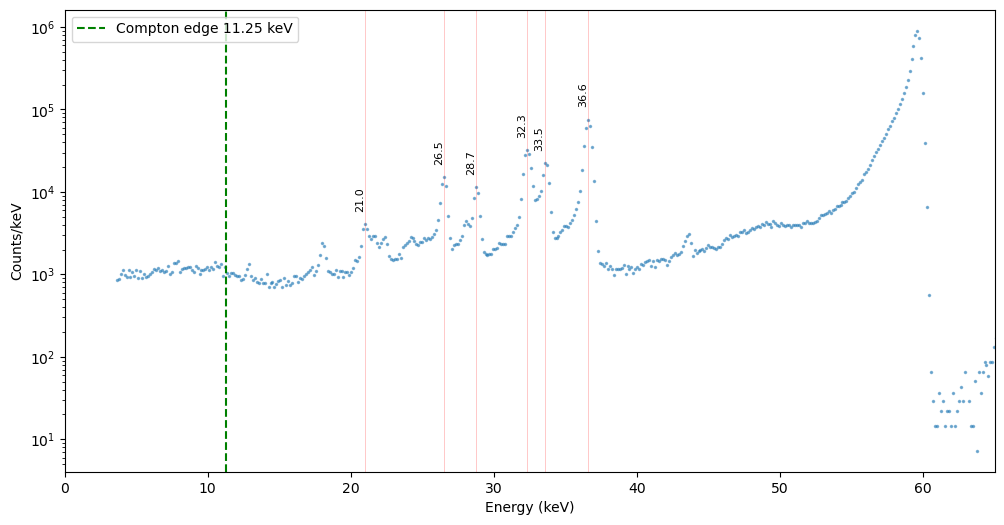

In [28]:
from scipy.signal import find_peaks

# Find peaks in the 8-50 keV region
mask_search = (E_binned > 7) & (E_binned < 55)
y_search = y_binned[mask_search]
E_search = E_binned[mask_search]

# Smooth slightly and find peaks above local background
peaks, props = find_peaks(y_search, prominence=y_search.max()*0.02, distance=5)

print(f"{'Energy (keV)':>14} {'Counts/keV':>12} {'Likely ID':>30}")
print("-"*60)
candidates = {
    8.0: 'Cu Kα', 8.6: 'Zn Kα', 8.9: 'Cu Kβ', 9.6: 'Zn Kβ',
    11.9: 'Au Lα (if Au present)', 13.95: 'Am-241 Lα',
    17.8: 'Am-241 Lβ', 20.8: 'Am-241 Lγ', 26.34: 'Am-241 γ',
    49.6: 'Ge K-escape from 59.54',
    57.8: 'Si K-escape from 59.54',
    48.3: 'Backscatter (180°)',
}
for p in peaks:
    E_p = E_search[p]
    nearest = min(candidates.items(), key=lambda kv: abs(kv[0]-E_p))
    label = nearest[1] if abs(nearest[0]-E_p) < 0.8 else '?'
    print(f"{E_p:>14.2f} {y_search[p]:>12.1f} {label:>30}")

fig, ax = plt.subplots(figsize=(12,6))
ax.semilogy(E_binned, y_binned, '.', ms=3, alpha=0.5)
for p in peaks:
    ax.axvline(E_search[p], color='r', alpha=0.3, lw=0.5)
    ax.text(E_search[p], y_search[p]*1.5, f'{E_search[p]:.1f}',
            rotation=90, fontsize=8, ha='right')
ax.set_xlim(0, 65); ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts/keV')
ax.axvline(T_max, color='g', ls='--', label=f'Compton edge {T_max:.2f} keV')
ax.legend(); plt.show()

In [30]:
# Peak exclusion windows (centers found above; width ~3σ on each side)
peak_centers = [8.0, 8.6, 13.95, 17.8, 20.8, 26.34]  # adjust to what you actually see
peak_halfwidths = [3 * sigma_of_E(E) for E in peak_centers]

def is_clean(E):
    """True for energies not within any peak window."""
    clean = np.ones_like(E, dtype=bool)
    for c, hw in zip(peak_centers, peak_halfwidths):
        clean &= np.abs(E - c) > hw
    return clean

# Fit region: clean Compton continuum below the edge
fit_mask = (E_binned > 2.0) & (E_binned < 10.0) & is_clean(E_binned)
E_data = E_binned[fit_mask]
y_data = y_binned[fit_mask]
y_err  = np.maximum(yerr_binned[fit_mask], 1.0)

print(f"Fitting {fit_mask.sum()} points after peak exclusion")

Fitting 49 points after peak exclusion


In [31]:
def full_model(T, amplitude, bg, *peak_amps):
    y = amplitude * kn_convolved(T) + bg
    for A, c in zip(peak_amps, peak_centers):
        sig = sigma_of_E(c)
        y = y + A * np.exp(-0.5*((T-c)/sig)**2) / (np.sqrt(2*np.pi)*sig)
    return y

p0 = [amp, 0.0] + [y_binned[np.argmin(np.abs(E_binned-c))] * sigma_of_E(c) * 2.5 
                    for c in peak_centers]
fit_mask_wide = (E_binned > 2.0) & (E_binned < 30.0)
popt_full, _ = curve_fit(full_model, E_binned[fit_mask_wide], y_binned[fit_mask_wide],
                         p0=p0, sigma=np.maximum(yerr_binned[fit_mask_wide], 1.0),
                         absolute_sigma=True)

Simultaneous KN + 8 Gaussians fit:
  KN amplitude = 1.301e+08 ± 0.000e+00
  Flat bg      = 2.073e+00 ± 3.013e-01
  χ²/dof = 41372.7/193 = 214.37

Peak         E (keV)    Area (cts/s)        ± err
Cu Kα           8.05         386.557       19.680
Zn Kα           8.64         379.662       21.438
Cu Kβ           8.91         347.531       20.674
Zn Kβ           9.57         425.840       20.656
Am Lα          13.95         376.239       19.422
Am Lβ          17.80         832.376       28.870
Am Lγ          20.80        1495.567       38.689
Am γ           26.34        5901.652       76.832


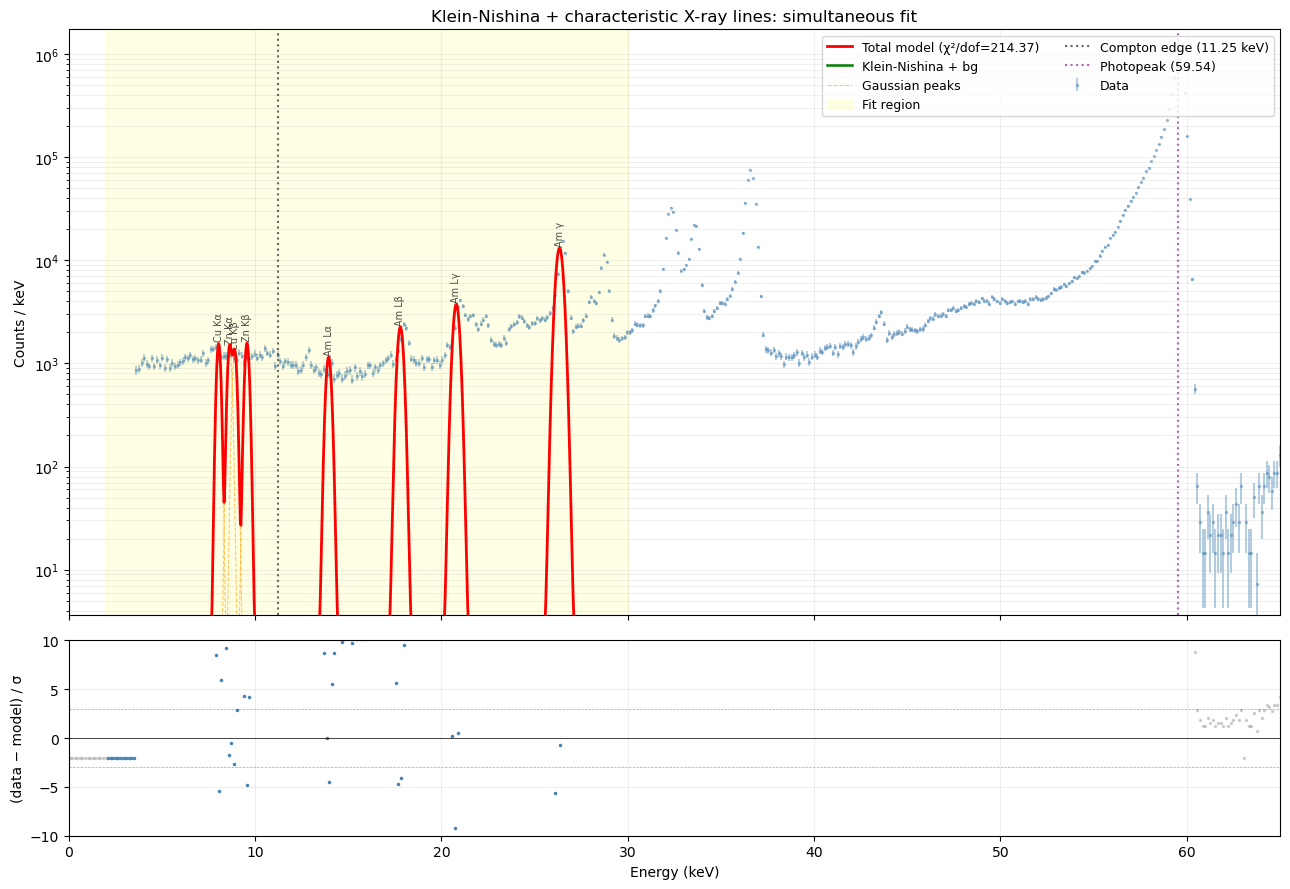

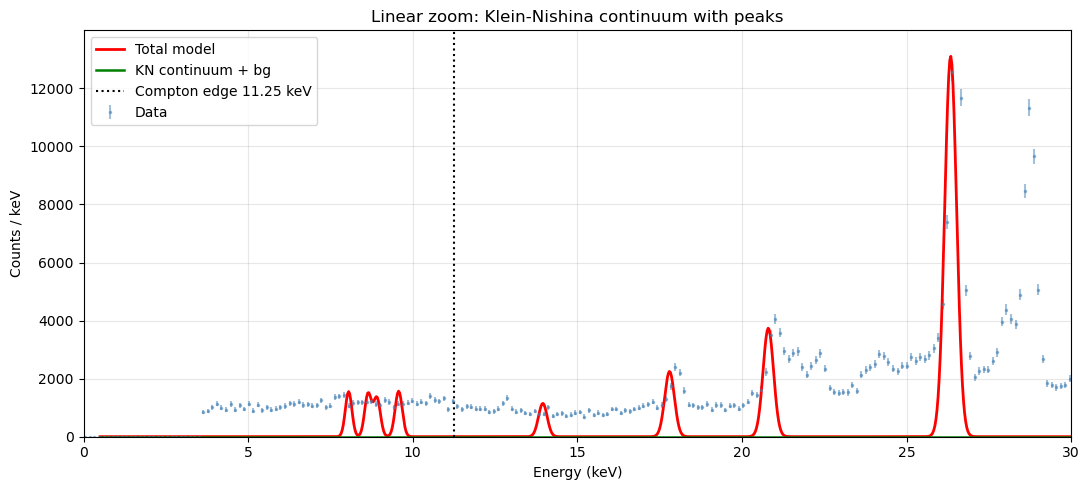

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Define the peak centers you identified ----
# EDIT THIS LIST based on what your peak-finder actually found
peak_info = [
    (8.05, 'Cu Kα'),
    (8.64, 'Zn Kα'),
    (8.91, 'Cu Kβ'),
    (9.57, 'Zn Kβ'),
    (13.95, 'Am Lα'),
    (17.8,  'Am Lβ'),
    (20.8,  'Am Lγ'),
    (26.34, 'Am γ'),
]
peak_centers = np.array([p[0] for p in peak_info])
peak_labels  = [p[1] for p in peak_info]
n_peaks = len(peak_centers)

# ---- Full model: KN continuum (convolved) + flat bg + sum of Gaussians ----
# Fix peak centers and widths (from resolution model); only amplitudes float.
def full_model(T, amplitude, bg, *peak_amps):
    y = amplitude * kn_convolved(T) + bg
    for A, c in zip(peak_amps, peak_centers):
        sig = sigma_of_E(c)
        y = y + A * np.exp(-0.5*((T-c)/sig)**2) / (np.sqrt(2*np.pi)*sig)
    return y

# ---- Fit region: from above noise threshold to just past the highest peak ----
fit_lo, fit_hi = 2.0, 30.0
fit_mask = (E_binned > fit_lo) & (E_binned < fit_hi)
E_data = E_binned[fit_mask]
y_data = y_binned[fit_mask]
y_err  = np.maximum(yerr_binned[fit_mask], 1.0)

# ---- Initial guesses ----
# Amplitude guess: scale KN to match the data near 5 keV (clean continuum region)
clean_pt = np.argmin(np.abs(E_data - 5.0))
amp0 = y_data[clean_pt] / max(kn_convolved(np.array([5.0]))[0], 1e-30)

# Peak amplitude guesses: Gaussian normalization * peak height
def peak_height_guess(c):
    idx = np.argmin(np.abs(E_binned - c))
    # Subtract rough KN baseline at this energy
    baseline = amp0 * kn_convolved(np.array([c]))[0] if c < T_max else 0.0
    sig = sigma_of_E(c)
    height = max(y_binned[idx] - baseline, 1.0)
    return height * sig * np.sqrt(2*np.pi)  # area = height * σ√(2π)

p0 = [amp0, 0.0] + [peak_height_guess(c) for c in peak_centers]
bounds_lo = [0, -np.inf] + [0]*n_peaks
bounds_hi = [np.inf, np.inf] + [np.inf]*n_peaks

popt_full, pcov_full = curve_fit(
    full_model, E_data, y_data,
    p0=p0, sigma=y_err, absolute_sigma=True,
    bounds=(bounds_lo, bounds_hi), maxfev=20000
)
perr_full = np.sqrt(np.diag(pcov_full))

amp_fit, bg_fit = popt_full[0], popt_full[1]
peak_amps_fit = popt_full[2:]
peak_amps_err = perr_full[2:]

# ---- Goodness of fit ----
chi2_full = np.sum(((y_data - full_model(E_data, *popt_full))/y_err)**2)
dof_full = len(y_data) - len(popt_full)
print(f"Simultaneous KN + {n_peaks} Gaussians fit:")
print(f"  KN amplitude = {amp_fit:.3e} ± {perr_full[0]:.3e}")
print(f"  Flat bg      = {bg_fit:.3e} ± {perr_full[1]:.3e}")
print(f"  χ²/dof = {chi2_full:.1f}/{dof_full} = {chi2_full/dof_full:.2f}\n")
print(f"{'Peak':<10} {'E (keV)':>9} {'Area (cts/s)':>15} {'± err':>12}")
for label, c, A, dA in zip(peak_labels, peak_centers, peak_amps_fit, peak_amps_err):
    print(f"{label:<10} {c:>9.2f} {A:>15.3f} {dA:>12.3f}")

# ---- Plot: data, total model, KN component, Gaussian components ----
T_plot = np.linspace(0.5, 65, 2000)
total = full_model(T_plot, *popt_full)
kn_component = amp_fit * kn_convolved(T_plot) + bg_fit
gaussian_components = []
for A, c in zip(peak_amps_fit, peak_centers):
    sig = sigma_of_E(c)
    gaussian_components.append(A * np.exp(-0.5*((T_plot-c)/sig)**2) / (np.sqrt(2*np.pi)*sig))

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={'height_ratios':[3,1]})

ax = axes[0]
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.4,
            color='steelblue', label='Data', zorder=1)
ax.plot(T_plot, total, 'r-', lw=2,
        label=f'Total model (χ²/dof={chi2_full/dof_full:.2f})', zorder=5)
ax.plot(T_plot, kn_component, 'g-', lw=1.8,
        label='Klein-Nishina + bg', zorder=4)
for i, (gc, label, c) in enumerate(zip(gaussian_components, peak_labels, peak_centers)):
    ax.plot(T_plot, gc + kn_component, '--', lw=0.8, alpha=0.6,
            color='orange', label='Gaussian peaks' if i==0 else None)
    ax.text(c, max(gc + kn_component)*1.05, label,
            rotation=90, fontsize=7, ha='center', va='bottom', alpha=0.7)

ax.axvspan(fit_lo, fit_hi, color='yellow', alpha=0.10, label='Fit region')
ax.axvline(T_max, color='k', ls=':', alpha=0.6, label=f'Compton edge ({T_max:.2f} keV)')
ax.axvline(E0, color='purple', ls=':', alpha=0.6, label='Photopeak (59.54)')

ax.set_yscale('log')
ax.set_ylabel('Counts / keV')
ax.set_ylim(bottom=max(0.5, y_binned[y_binned>0].min()*0.5))
ax.set_title('Klein-Nishina + characteristic X-ray lines: simultaneous fit')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, which='both', alpha=0.2)

# Residuals
ax2 = axes[1]
model_at_data = full_model(E_binned, *popt_full)
residuals = (y_binned - model_at_data) / np.maximum(yerr_binned, 1.0)
in_fit = (E_binned >= fit_lo) & (E_binned <= fit_hi)
ax2.plot(E_binned[in_fit], residuals[in_fit], '.', ms=3, color='steelblue')
ax2.plot(E_binned[~in_fit], residuals[~in_fit], '.', ms=3, color='gray', alpha=0.3)
ax2.axhline(0, color='k', lw=0.5)
for y in [-3, 3]:
    ax2.axhline(y, color='r', ls='--', lw=0.5, alpha=0.5)
ax2.set_xlabel('Energy (keV)')
ax2.set_ylabel('(data − model) / σ')
ax2.set_xlim(0, 65)
ax2.set_ylim(-10, 10)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ---- Linear-scale zoom on the KN continuum region ----
fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.5,
            color='steelblue', label='Data')
ax.plot(T_plot, total, 'r-', lw=2, label='Total model')
ax.plot(T_plot, kn_component, 'g-', lw=1.8, label='KN continuum + bg')
ax.axvline(T_max, color='k', ls=':', label=f'Compton edge {T_max:.2f} keV')
ax.set_xlim(0, 30)
ax.set_ylim(0, np.percentile(y_binned[(E_binned>2)&(E_binned<30)], 99)*1.2)
ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts / keV')
ax.set_title('Linear zoom: Klein-Nishina continuum with peaks')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

  Window 11.5-13.0 keV:  10 pts, mean = 1017.03, median = 972.06
  Window 15.0-17.0 keV:  14 pts, mean = 861.17, median = 863.25
  Window 22.5-25.5 keV:  22 pts, mean = 2208.89, median = 2343.09
  Window 28.0-45.0 keV: 124 pts, mean = 6657.04, median = 2350.35

Fixed background level B = 1991.268 ± 789.342 counts/keV
Initial KN amplitude guess: 5.671e+27
  Predicted KN excess at 5 keV: 199.13 counts/keV
  Data at 5 keV: 1138.90 counts/keV
  Difference (should be ≈ KN excess): -852.36

=== Fit results ===
KN amplitude = 4.941e-324 ± 0.000e+00
B (fixed)    = 1991.268
χ²/dof = 43641805.1/301 = 144989.39

Peak         E (keV)           Area       ± err
21.0 keV       21.01        877.323      45.867
22.4 keV       22.38        294.207      39.158
24.2 keV       24.18        413.690      40.702
26.5 keV       26.52       6085.114      87.636
28.7 keV       28.72       4359.337      77.243
32.3 keV       32.31      17659.602     139.170
33.5 keV       33.55      11088.471     113.205
36.6 ke

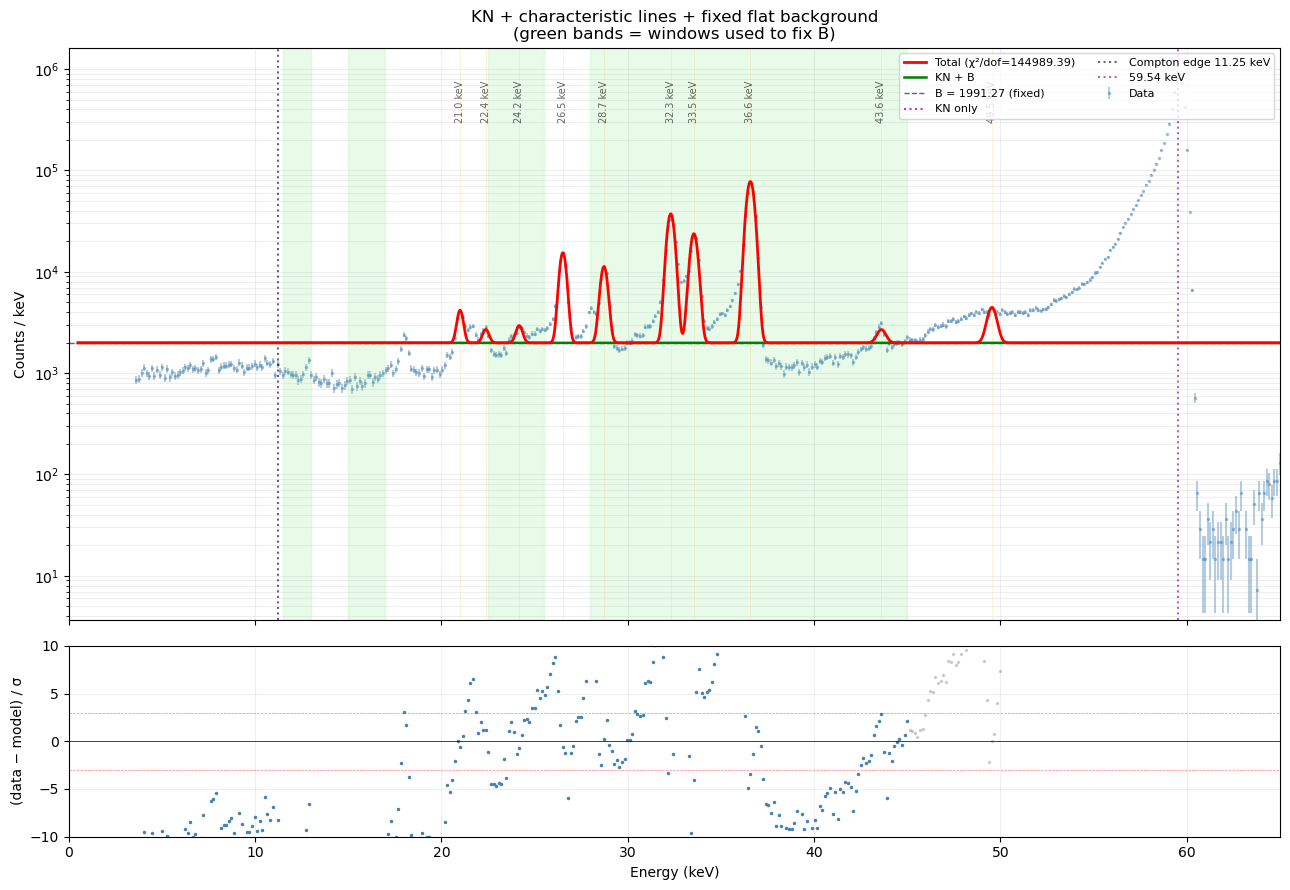

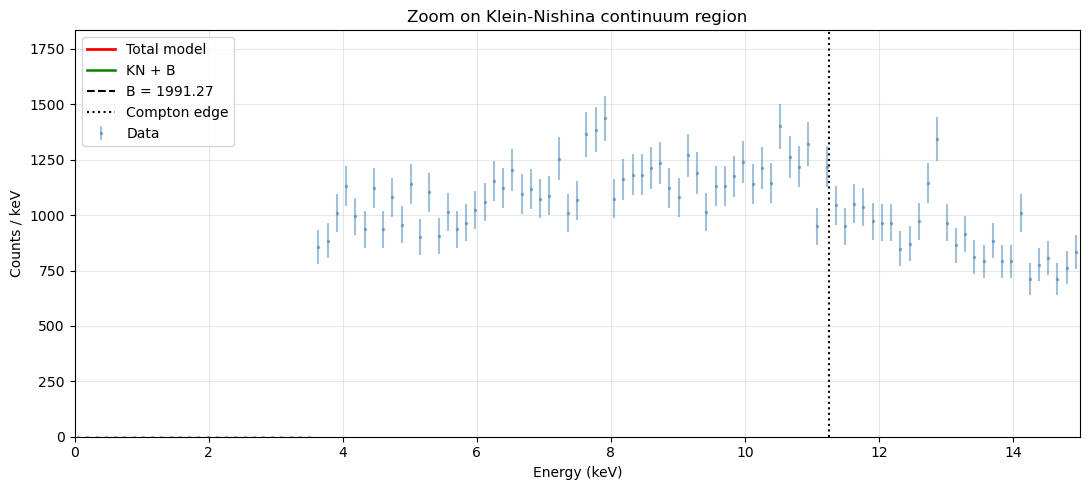

In [37]:
# ---- Stage 1: determine the constant background from peak-free regions ABOVE the Compton edge ----
# These regions should have NO Klein-Nishina contribution (KN = 0 for T > T_max).
# Pick narrow windows that sit between the Gaussian peaks.

# Inspect your spectrum and pick clean inter-peak windows. Examples (EDIT THESE):
bg_windows = [
    (11.5, 13.0),   # between Compton edge and Am Lα
    (15.0, 17.0),   # between Am Lα and Am Lβ
    (22.5, 25.5),   # between Am Lγ and Am γ
    (28.0, 45.0),   # above Am γ, below photopeak tail
]

bg_vals = []
for lo, hi in bg_windows:
    m = (E_binned > lo) & (E_binned < hi)
    if m.sum() > 0:
        bg_vals.append(y_binned[m])
        print(f"  Window {lo:.1f}-{hi:.1f} keV: {m.sum():3d} pts, "
              f"mean = {y_binned[m].mean():.2f}, median = {np.median(y_binned[m]):.2f}")

bg_all = np.concatenate(bg_vals)
B_fixed = np.median(bg_all)
B_err = np.std(bg_all) / np.sqrt(len(bg_all))
print(f"\nFixed background level B = {B_fixed:.3f} ± {B_err:.3f} counts/keV")

# ---- Stage 2: fit KN amplitude + Gaussian peaks, with B held FIXED ----
def model_fixed_bg(T, amplitude, *peak_amps):
    y = amplitude * kn_convolved(T) + B_fixed
    for A, c in zip(peak_amps, peak_centers):
        sig = sigma_of_E(c)
        y = y + A * np.exp(-0.5*((T-c)/sig)**2) / (np.sqrt(2*np.pi)*sig)
    return y

# Initial KN amplitude: subtract B from the data at ~5 keV
clean_idx = np.argmin(np.abs(E_binned - 5.0))
kn_at_5 = kn_convolved(np.array([5.0]))[0]
amp0 = max((y_binned[clean_idx] - B_fixed), B_fixed*0.1) / kn_at_5
print(f"Initial KN amplitude guess: {amp0:.3e}")
print(f"  Predicted KN excess at 5 keV: {amp0*kn_at_5:.2f} counts/keV")
print(f"  Data at 5 keV: {y_binned[clean_idx]:.2f} counts/keV")
print(f"  Difference (should be ≈ KN excess): {y_binned[clean_idx]-B_fixed:.2f}")

def peak_height_guess(c):
    idx = np.argmin(np.abs(E_binned - c))
    kn_here = amp0 * kn_convolved(np.array([c]))[0] if c < T_max else 0.0
    height = max(y_binned[idx] - kn_here - B_fixed, 1.0)
    return height * sigma_of_E(c) * np.sqrt(2*np.pi)

p0 = [amp0] + [peak_height_guess(c) for c in peak_centers]
bounds_lo = [0] + [0]*n_peaks
bounds_hi = [np.inf] + [np.inf]*n_peaks

fit_lo, fit_hi = 2.0, 45.0
fit_mask = (E_binned > fit_lo) & (E_binned < fit_hi)
E_data = E_binned[fit_mask]
y_data = y_binned[fit_mask]
y_err  = np.maximum(yerr_binned[fit_mask], 1.0)

popt, pcov = curve_fit(model_fixed_bg, E_data, y_data,
                       p0=p0, sigma=y_err, absolute_sigma=True,
                       bounds=(bounds_lo, bounds_hi), maxfev=50000)
perr = np.sqrt(np.diag(pcov))

amp_fit = popt[0]
peak_amps_fit = popt[1:]
peak_amps_err = perr[1:]

chi2 = np.sum(((y_data - model_fixed_bg(E_data, *popt))/y_err)**2)
dof = len(y_data) - len(popt)
print(f"\n=== Fit results ===")
print(f"KN amplitude = {amp_fit:.3e} ± {perr[0]:.3e}")
print(f"B (fixed)    = {B_fixed:.3f}")
print(f"χ²/dof = {chi2:.1f}/{dof} = {chi2/dof:.2f}")
print(f"\n{'Peak':<10} {'E (keV)':>9} {'Area':>14} {'± err':>11}")
for label, c, A, dA in zip(peak_labels, peak_centers, peak_amps_fit, peak_amps_err):
    print(f"{label:<10} {c:>9.2f} {A:>14.3f} {dA:>11.3f}")

# ---- Plot ----
T_plot = np.linspace(0.5, 65, 2000)
total = model_fixed_bg(T_plot, *popt)
kn_only = amp_fit * kn_convolved(T_plot)
kn_plus_bg = kn_only + B_fixed

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={'height_ratios':[3,1]})
ax = axes[0]
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.4,
            color='steelblue', label='Data', zorder=1)
ax.plot(T_plot, total, 'r-', lw=2,
        label=f'Total (χ²/dof={chi2/dof:.2f})', zorder=5)
ax.plot(T_plot, kn_plus_bg, 'g-', lw=1.8, label='KN + B', zorder=4)
ax.axhline(B_fixed, color='k', ls='--', lw=1.0, alpha=0.6,
           label=f'B = {B_fixed:.2f} (fixed)')
ax.plot(T_plot, kn_only, 'm:', lw=1.5, alpha=0.8, label='KN only')

# Mark the windows used for B determination
for lo, hi in bg_windows:
    ax.axvspan(lo, hi, color='lightgreen', alpha=0.2)

for label, c in zip(peak_labels, peak_centers):
    ax.axvline(c, color='orange', alpha=0.15, lw=0.7)
    ax.text(c, ax.get_ylim()[1]*0.5 if ax.get_yscale()=='linear' else 100,
            label, rotation=90, fontsize=7, ha='center', va='center', alpha=0.6)

ax.axvline(T_max, color='k', ls=':', alpha=0.6, label=f'Compton edge {T_max:.2f} keV')
ax.axvline(E0, color='purple', ls=':', alpha=0.6, label='59.54 keV')
ax.set_yscale('log')
ax.set_ylim(bottom=max(0.5, y_binned[y_binned>0].min()*0.5))
ax.set_ylabel('Counts / keV')
ax.set_title('KN + characteristic lines + fixed flat background\n'
             '(green bands = windows used to fix B)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.2)

ax2 = axes[1]
model_at_data = model_fixed_bg(E_binned, *popt)
residuals = (y_binned - model_at_data) / np.maximum(yerr_binned, 1.0)
in_fit = (E_binned >= fit_lo) & (E_binned <= fit_hi)
ax2.plot(E_binned[in_fit], residuals[in_fit], '.', ms=3, color='steelblue')
ax2.plot(E_binned[~in_fit], residuals[~in_fit], '.', ms=3, color='gray', alpha=0.3)
ax2.axhline(0, color='k', lw=0.5)
for y in [-3, 3]: ax2.axhline(y, color='r', ls='--', lw=0.5, alpha=0.5)
ax2.set_xlabel('Energy (keV)'); ax2.set_ylabel('(data − model) / σ')
ax2.set_xlim(0, 65); ax2.set_ylim(-10, 10); ax2.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# Linear-scale zoom on the KN region
fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.5,
            color='steelblue', label='Data')
ax.plot(T_plot, total, 'r-', lw=2, label='Total model')
ax.plot(T_plot, kn_plus_bg, 'g-', lw=1.8, label='KN + B')
ax.axhline(B_fixed, color='k', ls='--', label=f'B = {B_fixed:.2f}')
ax.axvline(T_max, color='k', ls=':', label=f'Compton edge')
ax.set_xlim(0, 15)
ymax_lin = np.percentile(y_binned[(E_binned>2)&(E_binned<12)], 99)*1.3
ax.set_ylim(0, ymax_lin)
ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts / keV')
ax.set_title('Zoom on Klein-Nishina continuum region')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Found 10 peaks above 600.9 cts/keV prominence:

   E (keV)     Height              Nearest candidate       ΔE
-----------------------------------------------------------------
     21.01     2078.3                          Am Lγ   +0.21  ←
     22.38      881.4                          Ag Kα   +0.22  ←
     24.18      859.6                          Sn Kα   -0.03  ←
     26.52    13278.7                           Am γ   +0.18  ←
     28.72     9347.0                          Te Kα   +1.25  ?
     32.31    30391.3                          Ba Kα   +0.12  ←
     33.55    20177.5                          Ba Kα   +1.36  ?
     36.58    73306.9                          Ba Kβ   +0.03  ←
     43.61     1128.0                       Ge K-esc   -5.99  ?
     49.54     2455.5                       Ge K-esc   -0.06  ←


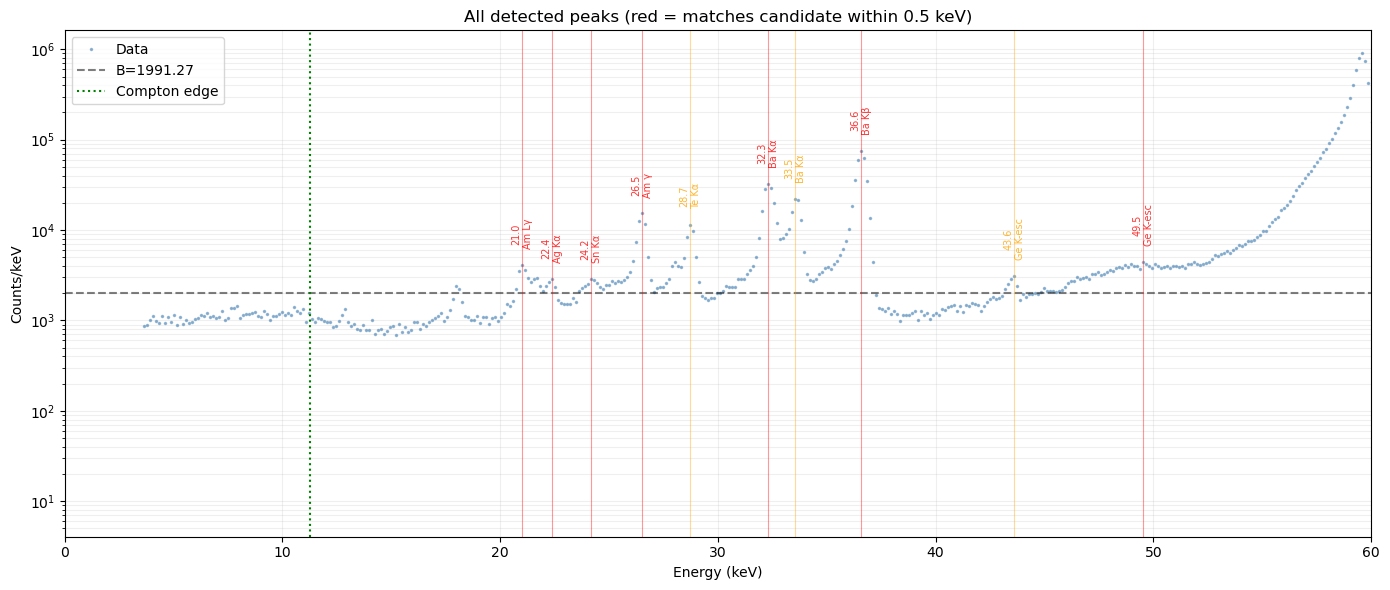

In [38]:
from scipy.signal import find_peaks

# ---- Find all significant peaks across the spectrum ----
# Subtract the fixed background first so peaks stand out cleanly
y_above_bg = np.maximum(y_binned - B_fixed, 0)

# Use the resolution model to set the minimum peak separation
min_sep_keV = 2 * sigma_of_E(20.0)  # ~ resolution at midrange energy
min_sep_bins = max(int(min_sep_keV / (E_binned[1]-E_binned[0])), 3)

# Search range: above noise threshold, below photopeak (and skip the photopeak itself)
search_mask = (E_binned > 3.0) & (E_binned < 55.0)
E_search = E_binned[search_mask]
y_search = y_above_bg[search_mask]

# Prominence threshold: peaks must rise at least N×sqrt(B) above background
prominence_thresh = 5 * np.sqrt(B_fixed / (rebin_factor * keV_per_ch))
peaks_idx, props = find_peaks(y_search,
                               prominence=prominence_thresh,
                               distance=min_sep_bins)

found_peaks_E = E_search[peaks_idx]
found_peaks_h = y_search[peaks_idx]

# Common candidate lines (extend this list as needed)
candidates = {
    8.05: 'Cu Kα', 8.64: 'Zn Kα', 8.91: 'Cu Kβ', 9.57: 'Zn Kβ',
    9.71: 'Au Lα',  11.44: 'Au Lβ', 13.38: 'Au Lγ',
    11.92: 'Pb Lℓ', 10.55: 'Pb Lα (low)', 12.61: 'Pb Lα', 14.76: 'Pb Lβ', 17.75: 'Pb Lγ',
    13.95: 'Am Lα', 17.8: 'Am Lβ', 20.8: 'Am Lγ', 26.34: 'Am γ',
    49.6: 'Ge K-esc',  57.8: 'Si K-esc',
    11.10: 'Br Kα',  # if any Br in plastics
    24.21: 'Sn Kα',  # solder
    25.27: 'Sn Kβ',
    22.16: 'Ag Kα', 24.94: 'Ag Kβ',  # silver electrodes / solder
    23.17: 'Cd Kα', 26.10: 'Cd Kβ',  # if CdTe detector
    27.47: 'Te Kα', 30.99: 'Te Kβ',
    32.19: 'Ba Kα', 36.55: 'Ba Kβ',  # glass
}

print(f"Found {len(found_peaks_E)} peaks above {prominence_thresh:.1f} cts/keV prominence:\n")
print(f"{'E (keV)':>10} {'Height':>10} {'Nearest candidate':>30} {'ΔE':>8}")
print("-"*65)
for E_p, h_p in zip(found_peaks_E, found_peaks_h):
    nearest_E, nearest_lbl = min(candidates.items(), key=lambda kv: abs(kv[0]-E_p))
    dE = E_p - nearest_E
    flag = "  ←" if abs(dE) < 0.5 else "  ?"
    print(f"{E_p:>10.2f} {h_p:>10.1f} {nearest_lbl:>30} {dE:>+7.2f}{flag}")

# ---- Plot found peaks on the spectrum ----
fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(E_binned, y_binned, '.', ms=3, alpha=0.5, color='steelblue', label='Data')
ax.axhline(B_fixed, color='k', ls='--', alpha=0.5, label=f'B={B_fixed:.2f}')
for E_p, h_p in zip(found_peaks_E, found_peaks_h):
    nearest_E, nearest_lbl = min(candidates.items(), key=lambda kv: abs(kv[0]-E_p))
    color = 'red' if abs(E_p - nearest_E) < 0.5 else 'orange'
    ax.axvline(E_p, color=color, alpha=0.4, lw=0.8)
    ax.text(E_p, (h_p + B_fixed)*1.5, f'{E_p:.1f}\n{nearest_lbl}',
            rotation=90, fontsize=7, ha='center', va='bottom', alpha=0.8, color=color)
ax.axvline(T_max, color='g', ls=':', label=f'Compton edge')
ax.set_xlim(0, 60)
ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts/keV')
ax.set_title('All detected peaks (red = matches candidate within 0.5 keV)')
ax.legend()
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout(); plt.show()

In [39]:
# Use found peaks directly without identification
peak_centers = found_peaks_E
peak_labels = [f'{E:.1f} keV' for E in found_peaks_E]
n_peaks = len(peak_centers)


=== Fit results ===
KN amplitude   = 4.941e-324 ± 0.000e+00
Photopeak σ    = 0.259 keV (compare to predicted 0.270)
χ²/dof = 48504840.1/444 = 109245.14

Peak                     E (keV)           Area       ± err
21.0 keV                   21.01         877.32       45.87
22.4 keV                   22.38         305.92       39.16
24.2 keV                   24.18         413.69       40.70
26.5 keV                   26.52        6085.11       87.64
28.7 keV                   28.72        4360.16       77.24
32.3 keV                   32.31       17659.60      139.17
33.5 keV                   33.55       11088.47      113.20
36.6 keV                   36.58       40265.90      205.92
43.6 keV                   43.61         473.61       46.35
49.5 keV                   49.54        1839.03       59.94
59.54 photopeak            59.54      595561.46      776.36


Text(0.5, 1.0, 'KN + characteristic lines + photopeak')

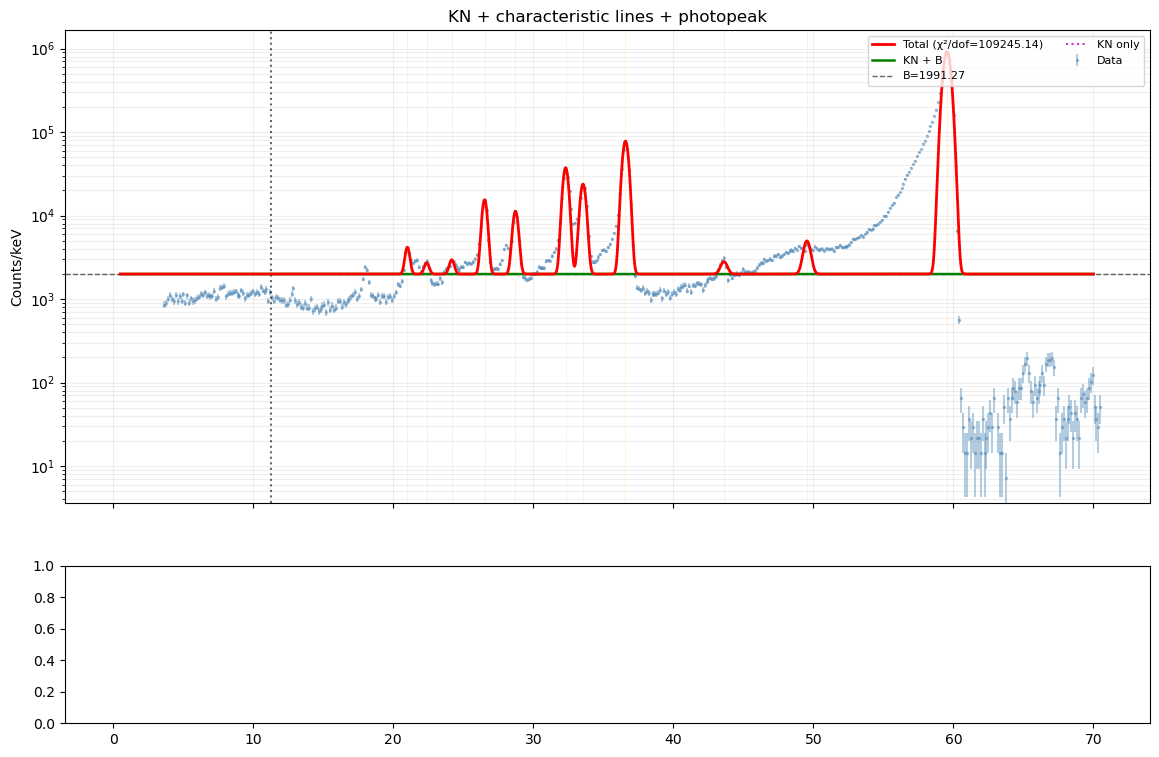

In [41]:
# ---- Add the 59.54 keV photopeak with its OWN free width (since it may be non-Gaussian) ----
# Plus extend fit range to include it
peak_centers_full = list(peak_centers) + [E0]
peak_labels_full  = list(peak_labels) + ['59.54 photopeak']
n_peaks_full = len(peak_centers_full)

def model_with_photopeak(T, amplitude, *params):
    peak_amps  = params[:n_peaks_full]      # one amplitude per peak
    pp_sigma   = params[n_peaks_full]       # free width for photopeak only
    
    y = amplitude * kn_convolved(T) + B_fixed
    for i, (A, c) in enumerate(zip(peak_amps, peak_centers_full)):
        sig = pp_sigma if c == E0 else sigma_of_E(c)
        y = y + A * np.exp(-0.5*((T-c)/sig)**2) / (np.sqrt(2*np.pi)*sig)
    return y

# Re-evaluate kn_convolved using the new sigma_of_E (it depends on it through resolution!)
# Need to redefine kn_convolved with the updated resolution function
def kn_convolved(T_eval, E=E0, n_fine=4000):
    T_max_local = 2*E**2 / (MEC2 + 2*E)
    T_fine = np.linspace(-5, T_max_local + 15, n_fine)
    dT = T_fine[1] - T_fine[0]
    kn_fine = klein_nishina_dsigma_dT(T_fine, E)
    result = np.zeros_like(T_eval, dtype=float)
    for i, T in enumerate(T_eval):
        sig = sigma_of_E(T)
        kernel = np.exp(-0.5*((T_fine - T)/sig)**2) / (np.sqrt(2*np.pi)*sig)
        result[i] = np.sum(kn_fine * kernel) * dT
    return result

# Initial guesses
amp0 = max((y_binned[np.argmin(np.abs(E_binned-5.0))] - B_fixed), B_fixed*0.1) / kn_convolved(np.array([5.0]))[0]

def peak_height_guess(c):
    idx = np.argmin(np.abs(E_binned - c))
    kn_here = amp0 * kn_convolved(np.array([c]))[0] if c < T_max else 0.0
    height = max(y_binned[idx] - kn_here - B_fixed, 1.0)
    sig = sigma_of_E(c) if c != E0 else sigma_pk_keV
    return height * sig * np.sqrt(2*np.pi)

p0 = [amp0] + [peak_height_guess(c) for c in peak_centers_full] + [sigma_pk_keV]
bounds_lo = [0] + [0]*n_peaks_full + [sigma_pk_keV*0.3]
bounds_hi = [np.inf] + [np.inf]*n_peaks_full + [sigma_pk_keV*5]

# Extend fit range to include photopeak
fit_lo, fit_hi = 2.0, 65.0
fit_mask = (E_binned > fit_lo) & (E_binned < fit_hi)
E_data = E_binned[fit_mask]
y_data = y_binned[fit_mask]
y_err  = np.maximum(yerr_binned[fit_mask], 1.0)

popt, pcov = curve_fit(model_with_photopeak, E_data, y_data,
                       p0=p0, sigma=y_err, absolute_sigma=True,
                       bounds=(bounds_lo, bounds_hi), maxfev=100000)
perr = np.sqrt(np.diag(pcov))

amp_fit = popt[0]
peak_amps_fit = popt[1:1+n_peaks_full]
pp_sigma_fit = popt[1+n_peaks_full]

chi2 = np.sum(((y_data - model_with_photopeak(E_data, *popt))/y_err)**2)
dof = len(y_data) - len(popt)
print(f"\n=== Fit results ===")
print(f"KN amplitude   = {amp_fit:.3e} ± {perr[0]:.3e}")
print(f"Photopeak σ    = {pp_sigma_fit:.3f} keV (compare to predicted {sigma_of_E(E0):.3f})")
print(f"χ²/dof = {chi2:.1f}/{dof} = {chi2/dof:.2f}\n")
print(f"{'Peak':<22} {'E (keV)':>9} {'Area':>14} {'± err':>11}")
for label, c, A, dA in zip(peak_labels_full, peak_centers_full, peak_amps_fit, perr[1:1+n_peaks_full]):
    print(f"{label:<22} {c:>9.2f} {A:>14.2f} {dA:>11.2f}")

# ---- Plot ----
T_plot = np.linspace(0.5, 70, 3000)
total = model_with_photopeak(T_plot, *popt)
kn_only = amp_fit * kn_convolved(T_plot)
kn_plus_bg = kn_only + B_fixed

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios':[3,1]})
ax = axes[0]
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.4,
            color='steelblue', label='Data', zorder=1)
ax.plot(T_plot, total, 'r-', lw=2, label=f'Total (χ²/dof={chi2/dof:.2f})', zorder=5)
ax.plot(T_plot, kn_plus_bg, 'g-', lw=1.8, label='KN + B', zorder=4)
ax.axhline(B_fixed, color='k', ls='--', lw=1.0, alpha=0.6, label=f'B={B_fixed:.2f}')
ax.plot(T_plot, kn_only, 'm:', lw=1.5, alpha=0.8, label='KN only')
for label, c in zip(peak_labels_full, peak_centers_full):
    ax.axvline(c, color='orange', alpha=0.15, lw=0.7)
ax.axvline(T_max, color='k', ls=':', alpha=0.6)
ax.set_yscale('log'); ax.set_ylabel('Counts/keV')
ax.set_ylim(bottom=max(0.5, y_binned[y_binned>0].min()*0.5))
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.2)
ax.set_title('KN + characteristic lines + photopeak')



<Figure size 640x480 with 0 Axes>

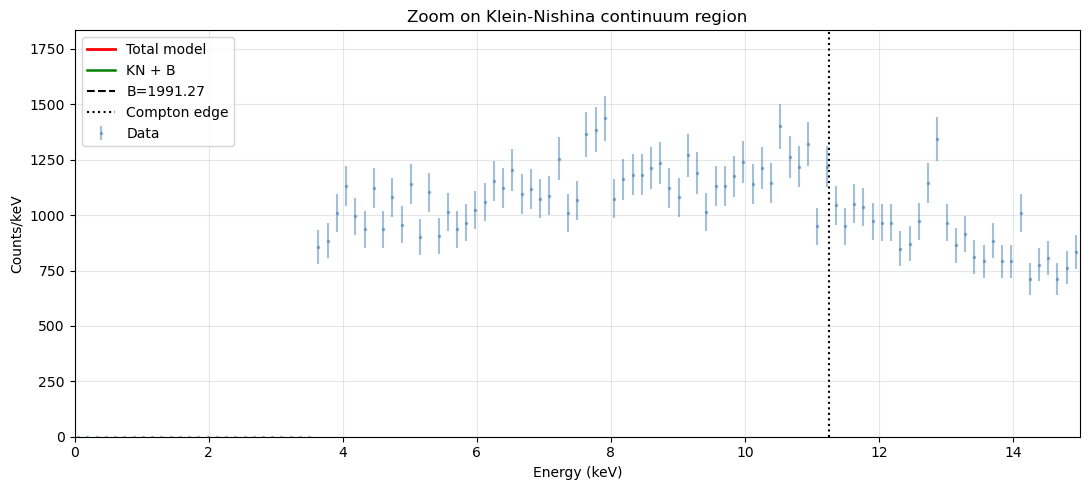

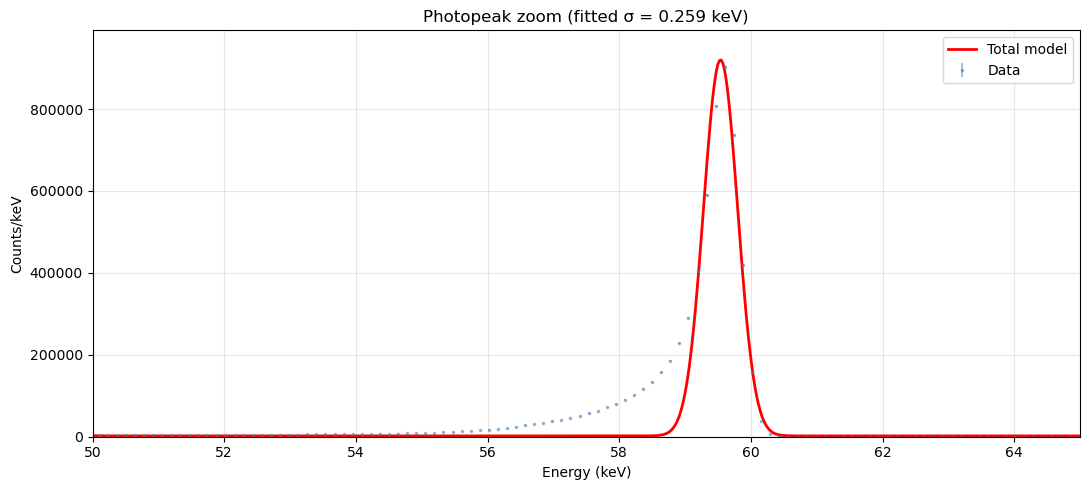

In [42]:
ax2 = axes[1]
residuals = (y_binned - model_with_photopeak(E_binned, *popt)) / np.maximum(yerr_binned, 1.0)
in_fit = (E_binned >= fit_lo) & (E_binned <= fit_hi)
ax2.plot(E_binned[in_fit], residuals[in_fit], '.', ms=3, color='steelblue')
ax2.plot(E_binned[~in_fit], residuals[~in_fit], '.', ms=3, color='gray', alpha=0.3)
ax2.axhline(0, color='k', lw=0.5)
for y in [-3, 3]: ax2.axhline(y, color='r', ls='--', lw=0.5, alpha=0.5)
ax2.set_xlabel('Energy (keV)'); ax2.set_ylabel('(data − model) / σ')
ax2.set_xlim(0, 70); ax2.set_ylim(-10, 10); ax2.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# ---- Linear-scale zoom on the KN continuum region ----
fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.5,
            color='steelblue', label='Data')
ax.plot(T_plot, total, 'r-', lw=2, label='Total model')
ax.plot(T_plot, kn_plus_bg, 'g-', lw=1.8, label='KN + B')
ax.axhline(B_fixed, color='k', ls='--', label=f'B={B_fixed:.2f}')
ax.axvline(T_max, color='k', ls=':', label='Compton edge')
ax.set_xlim(0, 15)
ymax_lin = np.percentile(y_binned[(E_binned>2)&(E_binned<12)], 99)*1.3
ax.set_ylim(0, ymax_lin)
ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts/keV')
ax.set_title('Zoom on Klein-Nishina continuum region')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- Linear-scale zoom on the photopeak ----
fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.5,
            color='steelblue', label='Data')
ax.plot(T_plot, total, 'r-', lw=2, label='Total model')
ax.set_xlim(50, 65)
m_zoom = (E_binned > 50) & (E_binned < 65)
ax.set_ylim(0, y_binned[m_zoom].max()*1.1)
ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts/keV')
ax.set_title(f'Photopeak zoom (fitted σ = {pp_sigma_fit:.3f} keV)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

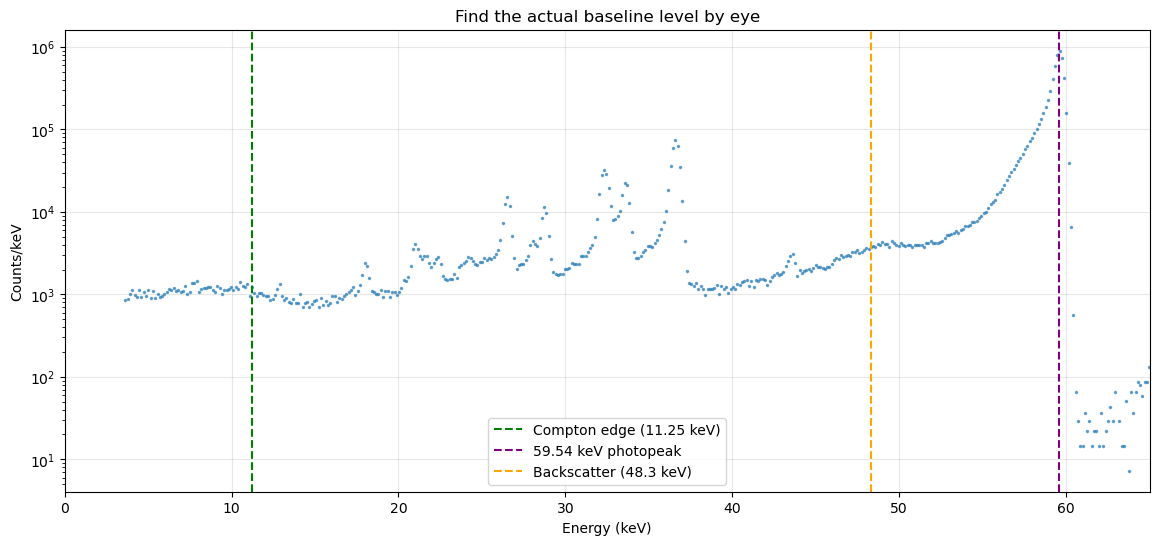

Actual data values in various regions:
    2-3   keV: median =     0.0, min =     0.0, max =     0.0, n_pts = 7
    4-5   keV: median =   993.8, min =   935.8, max =  1131.6, n_pts = 7
    6-7   keV: median =  1117.1, min =  1059.1, max =  1204.2, n_pts = 7
   12-13  keV: median =   964.8, min =   848.7, max =  1342.0, n_pts = 7
   15-17  keV: median =   863.2, min =   696.4, max =  1001.1, n_pts = 14
   22-25  keV: median =  2343.1, min =  1501.6, max =  2872.6, n_pts = 21
   28-40  keV: median =  3641.6, min =   979.3, max = 75298.2, n_pts = 87
   40-50  keV: median =  2154.5, min =  1160.7, max =  4446.8, n_pts = 73


In [43]:
# ---- Diagnostic: plot the spectrum and identify what's actually there ----
fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(E_binned, y_binned, '.', ms=3, alpha=0.6)
ax.axvline(T_max, color='g', ls='--', label=f'Compton edge ({T_max:.2f} keV)')
ax.axvline(E0, color='purple', ls='--', label='59.54 keV photopeak')
ax.axvline(E0 - T_max, color='orange', ls='--', label=f'Backscatter ({E0-T_max:.1f} keV)')
ax.set_xlim(0, 65)
ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts/keV')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Find the actual baseline level by eye')
plt.show()

# Print actual data values in candidate clean regions
print("Actual data values in various regions:")
for lo, hi in [(2,3), (4,5), (6,7), (12,13), (15,17), (22,25), (28,40), (40,50)]:
    m = (E_binned > lo) & (E_binned < hi)
    if m.sum() > 0:
        print(f"  {lo:>3}-{hi:<3} keV: median = {np.median(y_binned[m]):>7.1f}, "
              f"min = {y_binned[m].min():>7.1f}, max = {y_binned[m].max():>7.1f}, "
              f"n_pts = {m.sum()}")

True background B = 859.62 cts/keV (from 12-17 keV region)
Threshold midpoint estimated at: 3.50 keV

=== Fit results ===
KN amplitude    = 5.888e+27 ± 3.442e-24
Shelf height    = 577.8 ± 1.9
Shelf midpoint  = 20.05 ± 0.58 keV
Shelf slope     = 8.81 ± 0.62 keV
Photopeak σ     = 0.257 keV
χ²/dof = 2652615.5/427 = 6212.21



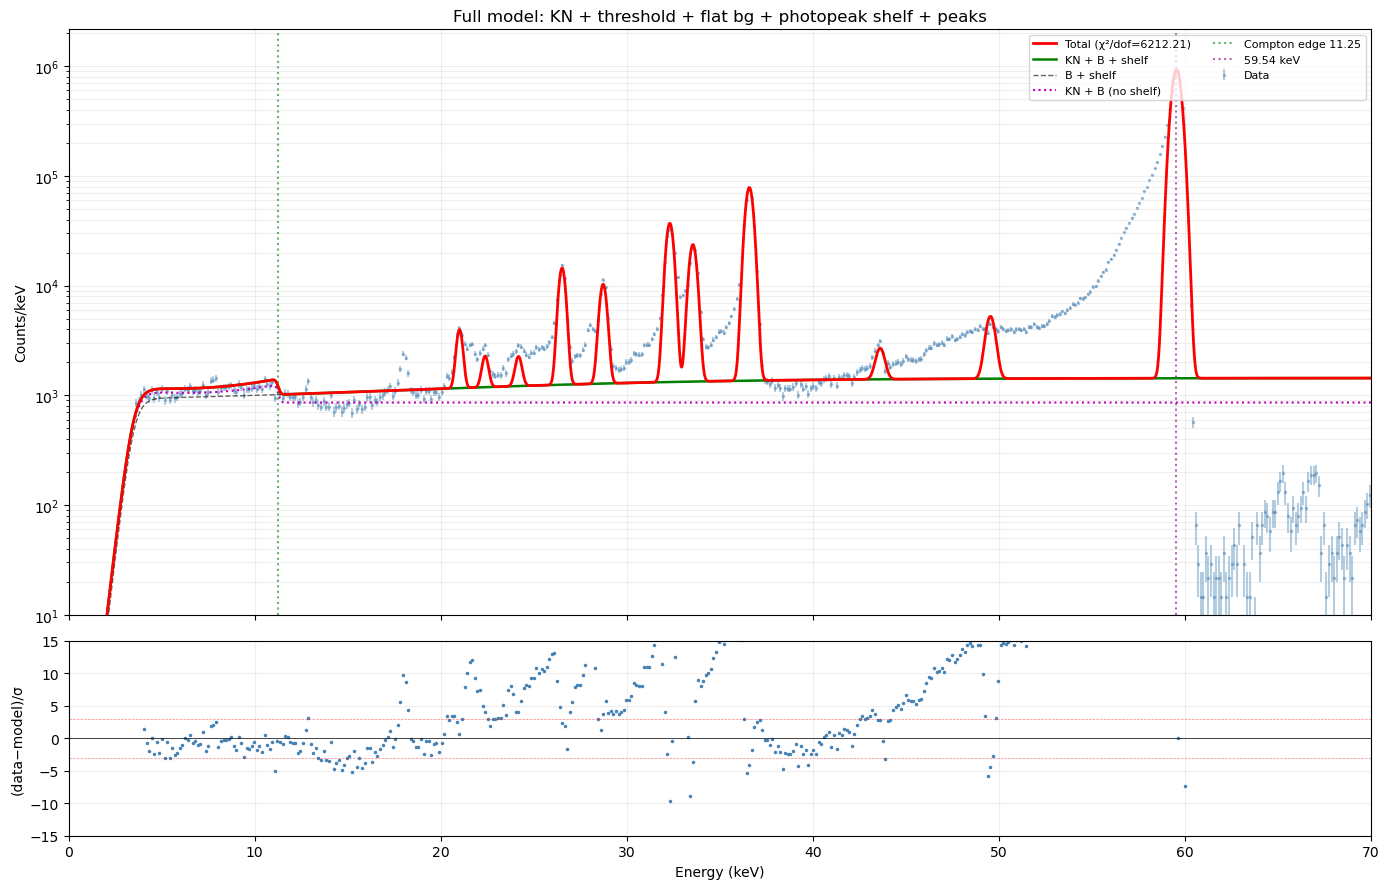

<Axes: title={'center': 'Zoom on KN continuum: green should sit above black by ~KN amount'}, xlabel='Energy (keV)', ylabel='Counts/keV'>

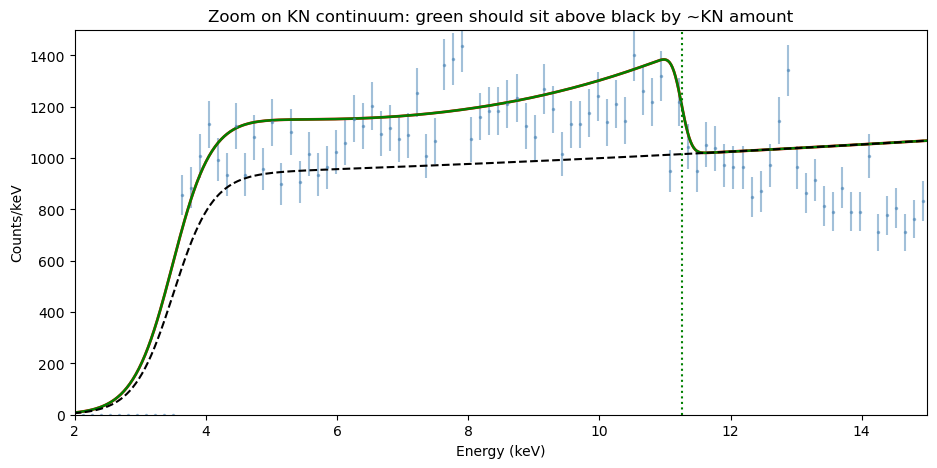

In [44]:
# ---- Set the TRUE background from the cleanest post-edge region ----
B_fixed = np.median(y_binned[(E_binned > 12) & (E_binned < 17)])
print(f"True background B = {B_fixed:.2f} cts/keV (from 12-17 keV region)")

# ---- Define a low-energy threshold function ----
# Sigmoid that smoothly cuts off counts below the threshold
def threshold(E, E_thr=3.0, width=0.3):
    return 1.0 / (1.0 + np.exp(-(E - E_thr)/width))

# Calibrate threshold from the data: where does the data drop to half of the 4-7 keV plateau?
plateau_level = np.median(y_binned[(E_binned > 4) & (E_binned < 7)])
half_level = plateau_level / 2
# Find where data crosses half_level on the rising edge
low_E_mask = (E_binned > 0.5) & (E_binned < 5.0)
crossings = np.where(np.diff(np.sign(y_binned[low_E_mask] - half_level)))[0]
if len(crossings) > 0:
    E_thr_measured = E_binned[low_E_mask][crossings[0]]
    print(f"Threshold midpoint estimated at: {E_thr_measured:.2f} keV")
else:
    E_thr_measured = 3.0
    print(f"Could not find threshold; defaulting to {E_thr_measured} keV")

# ---- Photopeak shelf: empirical rising background from incomplete charge collection ----
# This is roughly an error function rising from 0 at low E to a constant at high E,
# centered near the photopeak.
from scipy.special import erf
def shelf(E, height, center=E0, width=5.0):
    return 0.5 * height * (1 + erf((E - (center - 15))/width)) * (E < center - 1)

# Actually simpler: just use a smooth empirical function. Let's use a sigmoid shelf
# that rises starting around 22 keV and saturates around 40 keV.
def shelf(E, height, midpoint=30.0, slope=4.0):
    return height / (1.0 + np.exp(-(E - midpoint)/slope))

# ---- Full model: threshold * (KN + B + shelf + peaks) + photopeak ----
def full_model(T, amplitude, shelf_h, shelf_mid, shelf_slope, *params):
    n_p = len(peak_centers_full)
    peak_amps = params[:n_p]
    pp_sigma  = params[n_p]
    
    # Continuum components
    y = amplitude * kn_convolved(T) + B_fixed + shelf(T, shelf_h, shelf_mid, shelf_slope)
    
    # Apply low-energy threshold to continuum
    y = y * threshold(T, E_thr_measured, 0.3)
    
    # Add Gaussian peaks (also threshold-suppressed if at low E)
    for A, c in zip(peak_amps, peak_centers_full):
        sig = pp_sigma if c == E0 else sigma_of_E(c)
        peak_contribution = A * np.exp(-0.5*((T-c)/sig)**2) / (np.sqrt(2*np.pi)*sig)
        y = y + peak_contribution * threshold(T, E_thr_measured, 0.3)
    
    return y

# Initial guesses
amp0 = max((plateau_level - B_fixed), 50) / kn_convolved(np.array([5.0]))[0]
shelf_h0 = 1500  # roughly the elevation of the shelf in 28-50 keV region above B

def peak_height_guess(c):
    idx = np.argmin(np.abs(E_binned - c))
    sig = sigma_of_E(c) if c != E0 else sigma_pk_keV
    # Subtract estimated baseline at this energy
    baseline_here = B_fixed + (shelf_h0 if c > 22 else 0)
    height = max(y_binned[idx] - baseline_here, 1.0)
    return height * sig * np.sqrt(2*np.pi)

p0 = [amp0, shelf_h0, 30.0, 4.0] + [peak_height_guess(c) for c in peak_centers_full] + [sigma_pk_keV]
bounds_lo = [0, 0, 20, 1] + [0]*n_peaks_full + [sigma_pk_keV*0.3]
bounds_hi = [np.inf, np.inf, 50, 15] + [np.inf]*n_peaks_full + [sigma_pk_keV*5]

# Fit range: above threshold, including everything
fit_lo, fit_hi = 4.0, 65.0
fit_mask = (E_binned > fit_lo) & (E_binned < fit_hi)
E_data = E_binned[fit_mask]
y_data = y_binned[fit_mask]
y_err  = np.maximum(yerr_binned[fit_mask], 1.0)

popt, pcov = curve_fit(full_model, E_data, y_data,
                       p0=p0, sigma=y_err, absolute_sigma=True,
                       bounds=(bounds_lo, bounds_hi), maxfev=100000)
perr = np.sqrt(np.diag(pcov))

amp_fit, shelf_h_fit, shelf_mid_fit, shelf_slope_fit = popt[:4]
peak_amps_fit = popt[4:4+n_peaks_full]
pp_sigma_fit = popt[4+n_peaks_full]

chi2 = np.sum(((y_data - full_model(E_data, *popt))/y_err)**2)
dof = len(y_data) - len(popt)
print(f"\n=== Fit results ===")
print(f"KN amplitude    = {amp_fit:.3e} ± {perr[0]:.3e}")
print(f"Shelf height    = {shelf_h_fit:.1f} ± {perr[1]:.1f}")
print(f"Shelf midpoint  = {shelf_mid_fit:.2f} ± {perr[2]:.2f} keV")
print(f"Shelf slope     = {shelf_slope_fit:.2f} ± {perr[3]:.2f} keV")
print(f"Photopeak σ     = {pp_sigma_fit:.3f} keV")
print(f"χ²/dof = {chi2:.1f}/{dof} = {chi2/dof:.2f}\n")

# ---- Plot ----
T_plot = np.linspace(0.5, 70, 3000)
total = full_model(T_plot, *popt)
thr = threshold(T_plot, E_thr_measured, 0.3)
shelf_curve = shelf(T_plot, shelf_h_fit, shelf_mid_fit, shelf_slope_fit) * thr
kn_only = amp_fit * kn_convolved(T_plot) * thr
baseline = (B_fixed + shelf(T_plot, shelf_h_fit, shelf_mid_fit, shelf_slope_fit)) * thr
kn_plus_baseline = (amp_fit * kn_convolved(T_plot) + B_fixed 
                    + shelf(T_plot, shelf_h_fit, shelf_mid_fit, shelf_slope_fit)) * thr

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios':[3,1]})
ax = axes[0]
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.4,
            color='steelblue', label='Data', zorder=1)
ax.plot(T_plot, total, 'r-', lw=2, label=f'Total (χ²/dof={chi2/dof:.2f})', zorder=5)
ax.plot(T_plot, kn_plus_baseline, 'g-', lw=1.8, label='KN + B + shelf', zorder=4)
ax.plot(T_plot, baseline, 'k--', lw=1.0, alpha=0.6, label='B + shelf')
ax.plot(T_plot, kn_only + B_fixed*thr, 'm:', lw=1.5, label='KN + B (no shelf)')
ax.axvline(T_max, color='g', ls=':', alpha=0.6, label=f'Compton edge {T_max:.2f}')
ax.axvline(E0, color='purple', ls=':', alpha=0.6, label='59.54 keV')
ax.set_yscale('log'); ax.set_ylabel('Counts/keV')
ax.set_ylim(bottom=10)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.2)
ax.set_title('Full model: KN + threshold + flat bg + photopeak shelf + peaks')

ax2 = axes[1]
residuals = (y_binned - full_model(E_binned, *popt)) / np.maximum(yerr_binned, 1.0)
in_fit = (E_binned >= fit_lo) & (E_binned <= fit_hi)
ax2.plot(E_binned[in_fit], residuals[in_fit], '.', ms=3, color='steelblue')
ax2.axhline(0, color='k', lw=0.5)
for y in [-3, 3]: ax2.axhline(y, color='r', ls='--', lw=0.5, alpha=0.5)
ax2.set_xlabel('Energy (keV)'); ax2.set_ylabel('(data−model)/σ')
ax2.set_xlim(0, 70); ax2.set_ylim(-15, 15); ax2.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# Linear zoom on the KN region
fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(E_binned, y_binned, yerr=yerr_binned, fmt='.', ms=3, alpha=0.5,
            color='steelblue', label='Data')
ax.plot(T_plot, total, 'r-', lw=2, label='Total')
ax.plot(T_plot, kn_plus_baseline, 'g-', lw=1.8, label='KN + B + shelf')
ax.plot(T_plot, baseline, 'k--', label='B + shelf only')
ax.axvline(T_max, color='g', ls=':', label='Compton edge')
ax.set_xlim(2, 15); ax.set_ylim(0, 1500)
ax.set_xlabel('Energy (keV)'); ax.set_ylabel('Counts/keV')
ax.set_title('Zoom on KN continuum: green should sit above black by ~KN amount')
ax